In [ ]:
"""
Mini-batch gradient descent updates model parameters using small data subsets, balancing the speed of SGD and the stability of batch gradient
descent for efficient and stable training.
"""

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Generating Synthetic 2D Data

mean = np.array([5.0, 6.0])
cov = np.array([[1.0, 0.95], [0.95, 1.2]])
data = np.random.multivariate_normal(mean, cov, 8000)

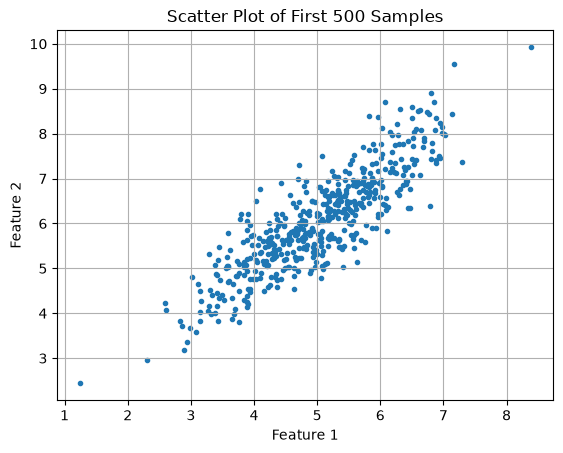

In [3]:
# Visualizing Generated Data

plt.scatter(data[:500, 0], data[:500, 1], marker='.')
plt.title("Scatter Plot of First 500 Samples")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

In [4]:
# Splitting Data

data = np.hstack((np.ones((data.shape[0], 1)), data))  

split_factor = 0.90
split = int(split_factor * data.shape[0])

X_train = data[:split, :-1]
y_train = data[:split, -1].reshape((-1, 1))
X_test = data[split:, :-1]
y_test = data[split:, -1].reshape((-1, 1))


In [5]:
# Displaying Datasets

print("Number of examples in training set = %d" % X_train.shape[0])
print("Number of examples in testing set = %d" % X_test.shape[0])

Number of examples in training set = 7200
Number of examples in testing set = 800


In [6]:
# Defining Core Functions of Linear Regression

def hypothesis(X, theta):
    return np.dot(X, theta)

def gradient(X, y, theta):
    h = hypothesis(X, theta)
    grad = np.dot(X.T, (h - y))
    return grad

def cost(X, y, theta):
    h = hypothesis(X, theta)
    J = np.dot((h - y).T, (h - y)) / 2
    return J[0]


In [7]:
# Creating Mini-Batches for Training

def create_mini_batches(X, y, batch_size):
    mini_batches = []
    data = np.hstack((X, y))
    np.random.shuffle(data)
    n_minibatches = data.shape[0] // batch_size
    for i in range(n_minibatches + 1):
        mini_batch = data[i * batch_size:(i + 1) * batch_size, :]
        X_mini = mini_batch[:, :-1]
        Y_mini = mini_batch[:, -1].reshape((-1, 1))
        mini_batches.append((X_mini, Y_mini))
    if data.shape[0] % batch_size != 0:
        mini_batch = data[i * batch_size:]
        X_mini = mini_batch[:, :-1]
        Y_mini = mini_batch[:, -1].reshape((-1, 1))
        mini_batches.append((X_mini, Y_mini))
    return mini_batches

In [8]:
# Mini-Batch Gradient Descent Function

def gradientDescent(X, y, learning_rate=0.001, batch_size=32):
    theta = np.zeros((X.shape[1], 1))
    error_list = []
    max_iters = 3

    for itr in range(max_iters):
        mini_batches = create_mini_batches(X, y, batch_size)
        for X_mini, y_mini in mini_batches:
            theta = theta - learning_rate * gradient(X_mini, y_mini, theta)
            error_list.append(cost(X_mini, y_mini, theta))

    return theta, error_list

Bias =  [0.78132548]
Coefficients =  [[1.04440355]]


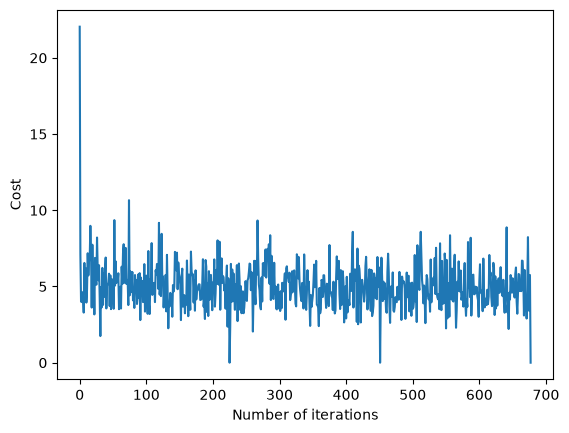

In [9]:
# Training and Visualization

theta, error_list = gradientDescent(X_train, y_train)
print("Bias = ", theta[0])
print("Coefficients = ", theta[1:])

plt.plot(error_list)
plt.xlabel("Number of iterations")
plt.ylabel("Cost")
plt.show()

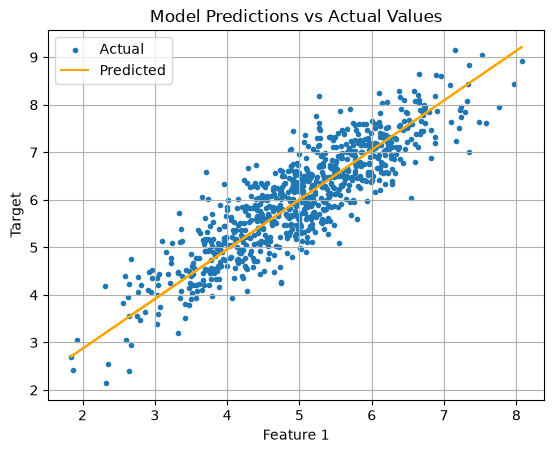

Mean Absolute Error = 0.44712643774760513


In [10]:
# Final Prediction and Evaluation

y_pred = hypothesis(X_test, theta)

plt.scatter(X_test[:, 1], y_test, marker='.', label='Actual')
plt.plot(X_test[:, 1], y_pred, color='orange', label='Predicted')
plt.xlabel("Feature 1")
plt.ylabel("Target")
plt.title("Model Predictions vs Actual Values")
plt.legend()
plt.grid(True)
plt.show()

error = np.sum(np.abs(y_test - y_pred)) / y_test.shape[0]
print("Mean Absolute Error =", error)
